# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Afdha Auliya Atiq
- **Email:** auliyaatiqafdha@apps.ipb.ac.id
- **ID Dicoding:** ds001b6y0696


## Menentukan Pertanyaan Bisnis

Dalam merumuskan pertanyaan bisnis untuk proyek analisis data ini, digunakan kerangka kerja **SMART** (*Specific, Measurable, Actionable, Relevant, Time-bound*) agar alur analisis terarah, terukur, dan memiliki konteks waktu yang jelas:

1. **Pertanyaan 1 (Tren & Performa Bisnis):**
   *Bagaimana performa dan tren total penyewaan sepeda (berdasarkan tipe pengguna: casual vs registered) selama periode tahun 2011 hingga 2012?*
   - **Specific:** Berfokus pada pertumbuhan volume penyewaan serta perbandingan antara pengguna kasual (*casual*) dan pengguna terdaftar (*registered*).
   - **Measurable:** Diukur dengan jumlah total penyewaan harian dan bulanan (`cnt`, `casual`, `registered`).
   - **Actionable:** Memberikan rekomendasi strategi konversi pengguna kasual menjadi pengguna terdaftar.
   - **Relevant:** Berdampak langsung pada proyeksi pertumbuhan dan strategi retensi bisnis.
   - **Time-bound:** Memiliki batasan rentang waktu yang jelas **selama periode tahun 2011 hingga 2012**.

2. **Pertanyaan 2 (Pola Jam Sibuk Operasional):**
   *Pada jam berapa saja terjadi lonjakan puncak (peak hours) dan titik terendah (off-peak hours) penyewaan sepeda pada hari kerja (working day) dibandingkan akhir pekan/hari libur (non-working day) selama periode tahun 2011 hingga 2012?*
   - **Specific:** Menganalisis perbedaan karakteristik jam sibuk peminjaman sepeda antara hari kerja (*working day*) dan akhir pekan/hari libur (*weekend/holiday*).
   - **Measurable:** Diukur dengan rata-rata jumlah penyewaan per jam (`hr`).
   - **Actionable:** Dasar pengalokasian ulang unit sepeda di stasiun komuter pada jam sibuk.
   - **Relevant:** Membantu efisiensi operasional dan manajemen pemeliharaan armada.
   - **Time-bound:** Memiliki batasan rentang waktu yang jelas **selama periode tahun 2011 hingga 2012**.

3. **Pertanyaan 3 (Faktor Musim & Cuaca):**
   *Bagaimana pengaruh kondisi cuaca (weathersit) dan musim (season) terhadap volume penyewaan sepeda harian oleh pengguna casual dan registered selama periode tahun 2011 hingga 2012?*
   - **Specific:** Mengukur dampak variasi kondisi cuaca dan musim terhadap tingkat peminjaman harian.
   - **Measurable:** Diukur dengan rerata penyewaan harian berdasarkan variabel `season_label` dan `weather_label`.
   - **Actionable:** Penyesuaian jadwal pemeliharaan dan program promosi saat cuaca atau musim tertentu.
   - **Relevant:** Meminimalkan potensi penurunan pendapatan akibat faktor cuaca buruk.
   - **Time-bound:** Memiliki batasan rentang waktu yang jelas **selama periode tahun 2011 hingga 2012**.


## Import Semua Packages/Library yang Digunakan


In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi gaya visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
print("Library berhasil diimpor dan konfigurasi style visualisasi telah diterapkan.")


Library berhasil diimpor dan konfigurasi style visualisasi telah diterapkan.


## Data Wrangling


### Gathering Data
Pada tahap ini, dataset penyewaan sepeda (`day.csv` dan `hour.csv`) dimuat ke dalam Pandas DataFrame untuk dianalisis lebih lanjut.


In [2]:
import os

# Menentukan jalur berkas
day_path = './data/day.csv' if os.path.exists('./data/day.csv') else 'day.csv'
hour_path = './data/hour.csv' if os.path.exists('./data/hour.csv') else 'hour.csv'

if not os.path.exists(day_path):
    day_path = r'C:\Users\Afdha\Documents\Proyek Analisis Data\bike_sharing_extracted\day.csv'
    hour_path = r'C:\Users\Afdha\Documents\Proyek Analisis Data\bike_sharing_extracted\hour.csv'

# Memuat data
day_df = pd.read_csv(day_path)
hour_df = pd.read_csv(hour_path)

print(f"Dataset Daily loaded: {day_df.shape[0]} baris, {day_df.shape[1]} kolom.")
print(f"Dataset Hourly loaded: {hour_df.shape[0]} baris, {hour_df.shape[1]} kolom.")
print("\n--- Lima Baris Pertama Data Harian (day_df) ---")
print(day_df.head())


Dataset Daily loaded: 731 baris, 16 kolom.
Dataset Hourly loaded: 17379 baris, 17 kolom.

--- Lima Baris Pertama Data Harian (day_df) ---
   instant      dteday  season  yr  ...  windspeed  casual  registered   cnt
0        1  2011-01-01       1   0  ...   0.160446     331         654   985
1        2  2011-01-02       1   0  ...   0.248539     131         670   801
2        3  2011-01-03       1   0  ...   0.248309     120        1229  1349
3        4  2011-01-04       1   0  ...   0.160296     108        1454  1562
4        5  2011-01-05       1   0  ...   0.186900      82        1518  1600

[5 rows x 16 columns]


**Insight Gathering Data:**
- Dataset harian (`day_df`) memiliki **731 entitas baris** dan **16 kolom**.
- Dataset per jam (`hour_df`) memiliki **17.379 entitas baris** dan **17 kolom**.
- Kedua dataset memuat variabel temporal (tanggal, jam, hari, musim), variabel cuaca (suhu, rasa suhu, kelembapan, kecepatan angin), serta variabel target peminjaman (*casual*, *registered*, *cnt*).


### Assessing Data
Tahap ini bertujuan untuk mengevaluasi kualitas data, mendeteksi keberadaan *missing values*, duplikasi data, anomali tipe data, serta nilai yang tidak konsisten.


In [3]:
print("=== Pemeriksaan Tipe Data & Missing Value pada day_df ===")
print(day_df.info())

print("\n=== Pemeriksaan Jumlah Missing Value pada day_df ===")
print(day_df.isna().sum())

print("\n=== Pemeriksaan Duplikasi Data ===")
print(f"Jumlah Duplikasi pada day_df: {day_df.duplicated().sum()}")
print(f"Jumlah Duplikasi pada hour_df: {hour_df.duplicated().sum()}")

print("\n=== Ringkasan Statistik Deskriptif (day_df) ===")
print(day_df.describe())


=== Pemeriksaan Tipe Data & Missing Value pada day_df ===
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB
None

=== Pemeriksaan Jumlah Missing Value pada da

**Steps to Take & Identifikasi Masalah Data:**
1. **Tipe Data Tidak Tepat (Invalid Data Type):** Kolom `dteday` tersimpan sebagai tipe data `object` (string). Langkah yang akan diambil adalah mengonversinya menjadi tipe data `datetime`.
2. **Nilai Kategorikal Terenkode Angka (Numeric Encoded Categories):** Kolom `season`, `weathersit`, `yr`, `mnth`, `weekday`, dan `workingday` berupa variabel numerik integer. Hal ini membuat pembacaan visual kurang intuitif. Langkah yang akan diambil adalah melakukan pemetaan (*mapping*) ke label deskriptif teks (misal: 1 -> Spring, 2 -> Summer, dll.).
3. **Variabel Kontinu Ter-normalisasi (Normalized Continuous Features):** Kolom `temp`, `atemp`, `hum`, dan `windspeed` berada pada rentang skala 0 hingga 1. Untuk keperluan interpretasi bisnis yang jelas, variabel ini akan di-denormalisasi ke dalam nilai riil ($\Phi_{temp} \times 41^\circ\text{C}$, $\Phi_{atemp} \times 50^\circ\text{C}$, $\Phi_{hum} \times 100\%$, $\Phi_{windspeed} \times 67 \text{ km/h}$).

**Insight Assessing Data:**
- Tidak ditemukan keberadaan *missing values* (0 null) dan tidak ada duplikasi data (0 duplicates) pada kedua dataset. Data sangat bersih secara struktur entitas dasar.


### Cleaning Data
Pada tahap ini, perbaikan dilakukan sesuai dengan rencana penanganan (*steps to take*) yang dirumuskan pada tahap Assessing Data.


In [4]:
# 1. Konversi dteday ke tipe data datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Pemetaan variabel kategorikal numerik ke label deskriptif
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {
    1: 'Clear / Few Clouds',
    2: 'Mist / Cloudy',
    3: 'Light Snow / Rain',
    4: 'Heavy Rain / Ice / Fog'
}
yr_map = {0: '2011', 1: '2012'}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
workingday_map = {0: 'Weekend / Holiday', 1: 'Working Day'}

# Terapkan pada day_df
day_df['season_label'] = day_df['season'].map(season_map)
day_df['weather_label'] = day_df['weathersit'].map(weather_map)
day_df['yr_label'] = day_df['yr'].map(yr_map)
day_df['weekday_label'] = day_df['weekday'].map(weekday_map)
day_df['workingday_label'] = day_df['workingday'].map(workingday_map)

# Terapkan pada hour_df
hour_df['season_label'] = hour_df['season'].map(season_map)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)
hour_df['yr_label'] = hour_df['yr'].map(yr_map)
hour_df['weekday_label'] = hour_df['weekday'].map(weekday_map)
hour_df['workingday_label'] = hour_df['workingday'].map(workingday_map)

# 3. Denormalisasi variabel kontinu untuk interpretasi riil
day_df['temp_c'] = day_df['temp'] * 41
day_df['atemp_c'] = day_df['atemp'] * 50
day_df['hum_pct'] = day_df['hum'] * 100
day_df['windspeed_kmh'] = day_df['windspeed'] * 67

hour_df['temp_c'] = hour_df['temp'] * 41
hour_df['atemp_c'] = hour_df['atemp'] * 50
hour_df['hum_pct'] = hour_df['hum'] * 100
hour_df['windspeed_kmh'] = hour_df['windspeed'] * 67

print("=== Verifikasi Struktur Data Setelah Cleaning (day_df) ===")
print(day_df[['dteday', 'season_label', 'weather_label', 'yr_label', 'temp_c', 'hum_pct', 'cnt']].head())


=== Verifikasi Struktur Data Setelah Cleaning (day_df) ===
      dteday season_label       weather_label  ...     temp_c  hum_pct   cnt
0 2011-01-01       Spring       Mist / Cloudy  ...  14.110847  80.5833   985
1 2011-01-02       Spring       Mist / Cloudy  ...  14.902598  69.6087   801
2 2011-01-03       Spring  Clear / Few Clouds  ...   8.050924  43.7273  1349
3 2011-01-04       Spring  Clear / Few Clouds  ...   8.200000  59.0435  1562
4 2011-01-05       Spring  Clear / Few Clouds  ...   9.305237  43.6957  1600

[5 rows x 7 columns]


**Insight Cleaning Data:**
- Tipe data `dteday` kini sukses dikonversi menjadi `datetime64[ns]`.
- Kolom kategorikal baru dengan akhiran `_label` berhasil dibuat untuk memudahkan visualisasi dan agregasi data.
- Nilai suhu, kelembapan, dan kecepatan angin kini tersaji dalam satuan pengukuran riil ($^\circ\text{C}$, $\%$, dan $\text{km/h}$).


## Exploratory Data Analysis (EDA)

Pada tahap Exploratory Data Analysis (EDA) komprehensif ini, eksplorasi data dilakukan secara mendalam untuk memahami karakteristik statistik data, distribusi variabel, korelasi antar variabel, serta pola agregasi bisnis:

1. **EDA Univariate (Analisis Variabel Tunggal):**
   - **Variabel Numerik Kontinu:** Analisis deskriptif (Mean, Std, Min, Median, Max, Skewness, Kurtosis) dan visualisasi distribusi menggunakan **Histogram dengan KDE Plot** serta **Boxplot** untuk mendeteksi sebaran data dan pencilan (*outliers*) pada `day_df` dan `hour_df`.
   - **Variabel Kategorikal:** Distribusi frekuensi, proporsi persentase, dan visualisasi **Countplot / Bar Plot** untuk variabel kategori (`season_label`, `weather_label`, `workingday_label`, `yr_label`, `mnth`).

2. **EDA Bivariate & Multivariate (Analisis Hubungan Antar Variabel):**
   - **Matriks Korelasi & Heatmap:** Analisis koefisien korelasi Pearson antar seluruh variabel numerik kontinu untuk mendeteksi variabel yang berpengaruh kuat terhadap total penyewaan (`cnt`).
   - **Pairplot & Scatter Plot:** Eksplorasi matriks sebaran dan korelasi linear antara suhu (`temp_c`), kelembapan (`hum_pct`), kecepatan angin (`windspeed_kmh`), serta total penyewaan sepeda (`cnt`).
   - **Variabel Kategorikal vs Numerikal Target (`cnt`):** Visualisasi **Boxplot** dan **Bar Plot** sebaran volume penyewaan (`cnt`, `casual`, `registered`) berdasarkan Musim (`season_label`), Cuaca (`weather_label`), dan Tipe Hari (`workingday_label`).

3. **EDA Agregasi & Groupby:**
   - Pengelompokan data spesifik untuk menggali pola dasar dalam menjawab pertanyaan bisnis utama (Tren Bulanan, Pola Jam Sibuk, dan Pengaruh Cuaca/Musim).


=== 1. Statistik Deskriptif Variabel Numerik Kontinu (day_df) ===
                  mean      std    min      50%      max  skewness  kurtosis
temp_c           20.31     7.51   2.42    20.43    35.33     -0.05     -1.12
atemp_c          23.72     8.15   3.95    24.34    42.04     -0.13     -0.99
hum_pct          62.79    14.24   0.00    62.67    97.25     -0.07     -0.06
windspeed_kmh    12.76     5.19   1.50    12.13    34.00      0.68      0.41
casual          848.18   686.62   2.00   713.00  3410.00      1.27      1.32
registered     3656.17  1560.26  20.00  3662.00  6946.00      0.04     -0.71
cnt            4504.35  1937.21  22.00  4548.00  8714.00     -0.05     -0.81

=== 2. Statistik Deskriptif Variabel Numerik Kontinu (hour_df) ===
                 mean     std   min     50%    max  skewness
temp_c          20.38    7.89  0.82   20.50   41.0     -0.01
atemp_c         23.79    8.59  0.00   24.24   50.0     -0.09
hum_pct         62.72   19.29  0.00   63.00  100.0     -0.11
windsp

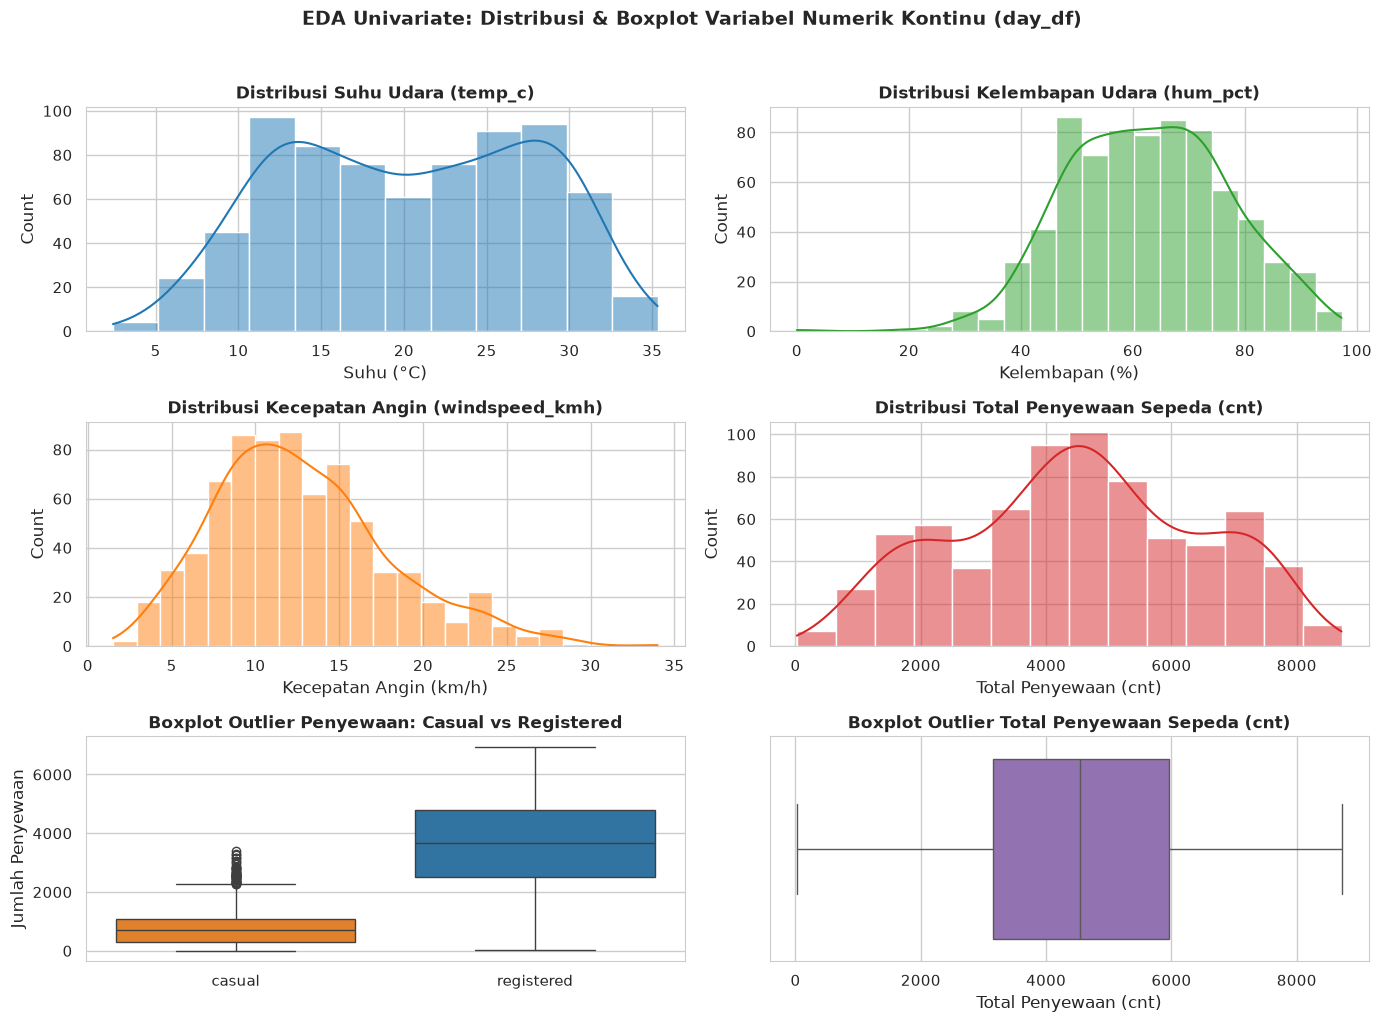

In [5]:
# ==============================================================================
# 1. EDA UNIVARIATE: Analisis Variabel Numerik Kontinu (Distribution & Outliers)
# ==============================================================================

num_cols = ['temp_c', 'atemp_c', 'hum_pct', 'windspeed_kmh', 'casual', 'registered', 'cnt']

print("=== 1. Statistik Deskriptif Variabel Numerik Kontinu (day_df) ===")
stats_day = day_df[num_cols].describe().T
stats_day['skewness'] = day_df[num_cols].skew()
stats_day['kurtosis'] = day_df[num_cols].kurtosis()
print(stats_day[['mean', 'std', 'min', '50%', 'max', 'skewness', 'kurtosis']].round(2))

print("\n=== 2. Statistik Deskriptif Variabel Numerik Kontinu (hour_df) ===")
stats_hour = hour_df[num_cols].describe().T
stats_hour['skewness'] = hour_df[num_cols].skew()
print(stats_hour[['mean', 'std', 'min', '50%', 'max', 'skewness']].round(2))

# Visualisasi Distribusi & Boxplot Variabel Numerik Utama (day_df)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('EDA Univariate: Distribusi & Boxplot Variabel Numerik Kontinu (day_df)', fontsize=14, fontweight='bold', y=1.02)

# Temp
sns.histplot(day_df['temp_c'], kde=True, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Distribusi Suhu Udara (temp_c)', fontweight='bold')
axes[0, 0].set_xlabel('Suhu (°C)')

# Humidity
sns.histplot(day_df['hum_pct'], kde=True, ax=axes[0, 1], color='#2ca02c')
axes[0, 1].set_title('Distribusi Kelembapan Udara (hum_pct)', fontweight='bold')
axes[0, 1].set_xlabel('Kelembapan (%)')

# Windspeed
sns.histplot(day_df['windspeed_kmh'], kde=True, ax=axes[1, 0], color='#ff7f0e')
axes[1, 0].set_title('Distribusi Kecepatan Angin (windspeed_kmh)', fontweight='bold')
axes[1, 0].set_xlabel('Kecepatan Angin (km/h)')

# Total Rentals (cnt)
sns.histplot(day_df['cnt'], kde=True, ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('Distribusi Total Penyewaan Sepeda (cnt)', fontweight='bold')
axes[1, 1].set_xlabel('Total Penyewaan (cnt)')

# Boxplot Casual vs Registered
sns.boxplot(data=day_df[['casual', 'registered']], ax=axes[2, 0], palette=['#ff7f0e', '#1f77b4'])
axes[2, 0].set_title('Boxplot Outlier Penyewaan: Casual vs Registered', fontweight='bold')
axes[2, 0].set_ylabel('Jumlah Penyewaan')

# Boxplot Total Rentals (cnt)
sns.boxplot(x=day_df['cnt'], ax=axes[2, 1], color='#9467bd')
axes[2, 1].set_title('Boxplot Outlier Total Penyewaan Sepeda (cnt)', fontweight='bold')
axes[2, 1].set_xlabel('Total Penyewaan (cnt)')

plt.tight_layout()
plt.show()


=== Distribusi Frekuensi Variabel Kategorikal (day_df) ===

--- Distribusi season_label ---
              Jumlah Hari  Persentase (%)
season_label                             
Fall                  188           25.72
Summer                184           25.17
Spring                181           24.76
Winter                178           24.35

--- Distribusi weather_label ---
                    Jumlah Hari  Persentase (%)
weather_label                                  
Clear / Few Clouds          463           63.34
Mist / Cloudy               247           33.79
Light Snow / Rain            21            2.87

--- Distribusi workingday_label ---
                   Jumlah Hari  Persentase (%)
workingday_label                              
Working Day                500            68.4
Weekend / Holiday          231            31.6

--- Distribusi yr_label ---
          Jumlah Hari  Persentase (%)
yr_label                             
2012              366           50.07
2011          

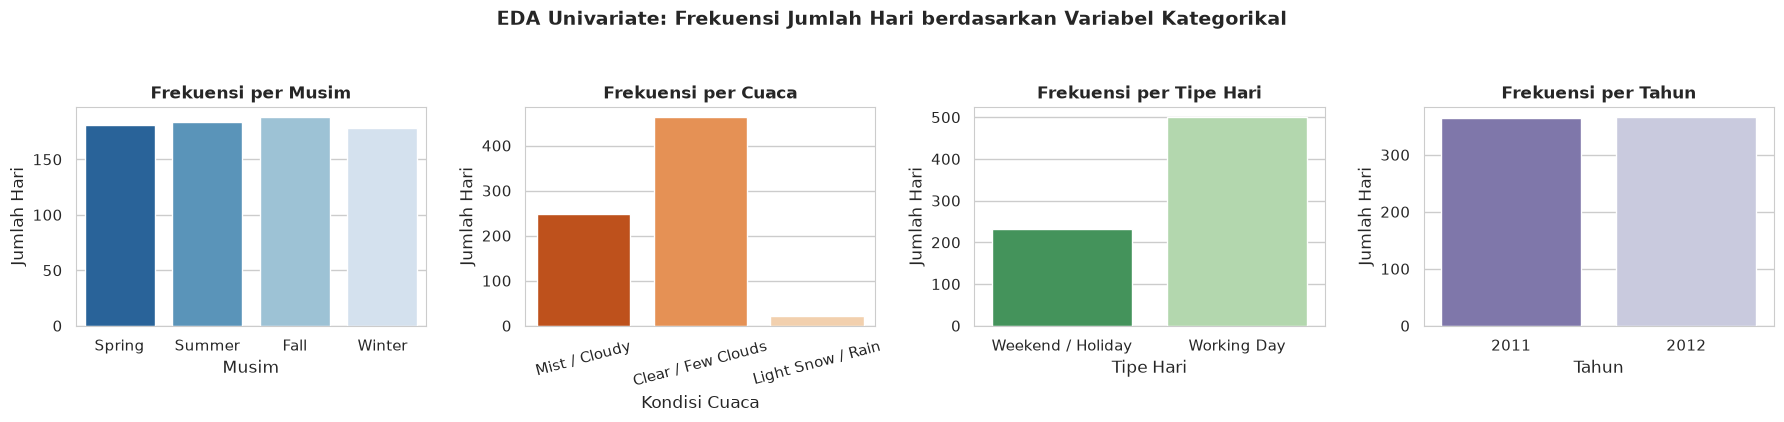

In [6]:
# ==============================================================================
# 2. EDA UNIVARIATE: Analisis Variabel Kategorikal
# ==============================================================================

print("=== Distribusi Frekuensi Variabel Kategorikal (day_df) ===")
for cat_col in ['season_label', 'weather_label', 'workingday_label', 'yr_label']:
    print("\n--- Distribusi " + str(cat_col) + " ---")
    val_counts = day_df[cat_col].value_counts()
    val_pct = day_df[cat_col].value_counts(normalize=True) * 100
    df_cat_summary = pd.DataFrame({'Jumlah Hari': val_counts, 'Persentase (%)': val_pct.round(2)})
    print(df_cat_summary)

# Visualisasi Bar Plot Variabel Kategorikal
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('EDA Univariate: Frekuensi Jumlah Hari berdasarkan Variabel Kategorikal', fontsize=14, fontweight='bold', y=1.05)

sns.countplot(data=day_df, x='season_label', ax=axes[0], palette='Blues_r', order=['Spring', 'Summer', 'Fall', 'Winter'])
axes[0].set_title('Frekuensi per Musim', fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Jumlah Hari')

sns.countplot(data=day_df, x='weather_label', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Frekuensi per Cuaca', fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Jumlah Hari')
axes[1].tick_params(axis='x', rotation=15)

sns.countplot(data=day_df, x='workingday_label', ax=axes[2], palette='Greens_r')
axes[2].set_title('Frekuensi per Tipe Hari', fontweight='bold')
axes[2].set_xlabel('Tipe Hari')
axes[2].set_ylabel('Jumlah Hari')

sns.countplot(data=day_df, x='yr_label', ax=axes[3], palette='Purples_r')
axes[3].set_title('Frekuensi per Tahun', fontweight='bold')
axes[3].set_xlabel('Tahun')
axes[3].set_ylabel('Jumlah Hari')

plt.tight_layout()
plt.show()


=== Matriks Korelasi Pearson Variabel Numerik Kontinu ===
               temp_c  atemp_c  hum_pct  ...  casual  registered    cnt
temp_c          1.000    0.992    0.127  ...   0.543       0.540  0.627
atemp_c         0.992    1.000    0.140  ...   0.544       0.544  0.631
hum_pct         0.127    0.140    1.000  ...  -0.077      -0.091 -0.101
windspeed_kmh  -0.158   -0.184   -0.248  ...  -0.168      -0.217 -0.235
casual          0.543    0.544   -0.077  ...   1.000       0.395  0.673
registered      0.540    0.544   -0.091  ...   0.395       1.000  0.946
cnt             0.627    0.631   -0.101  ...   0.673       0.946  1.000

[7 rows x 7 columns]


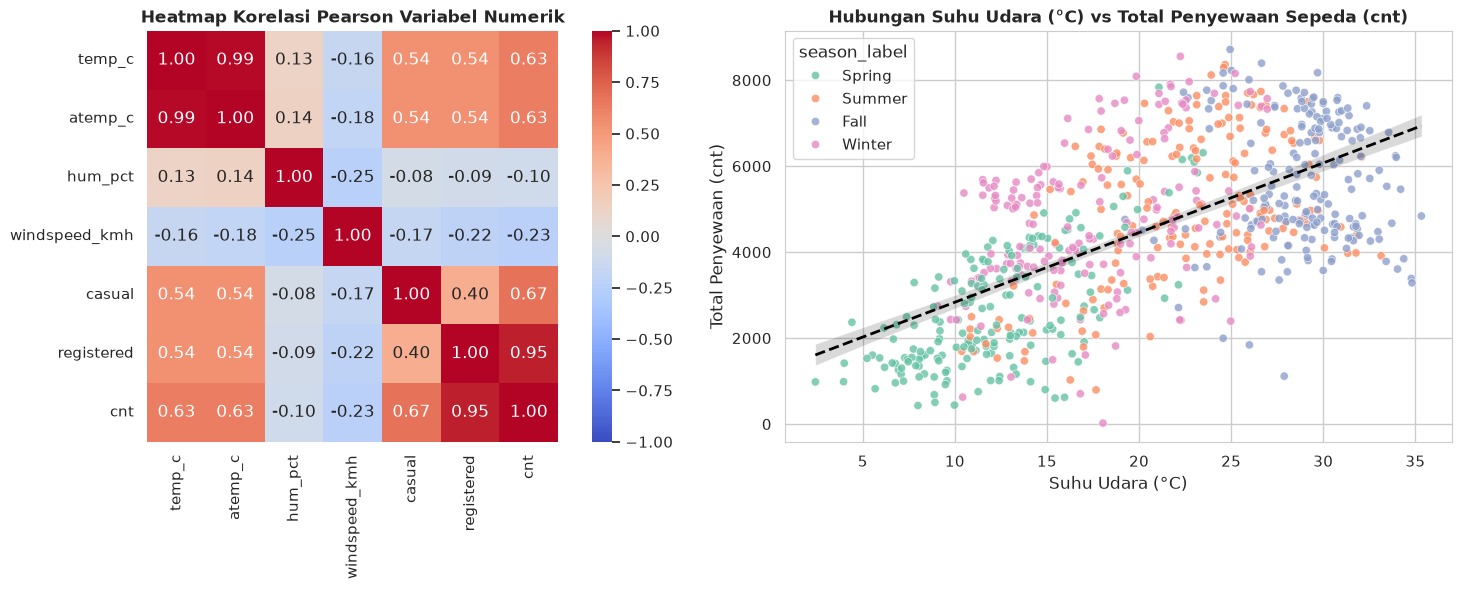

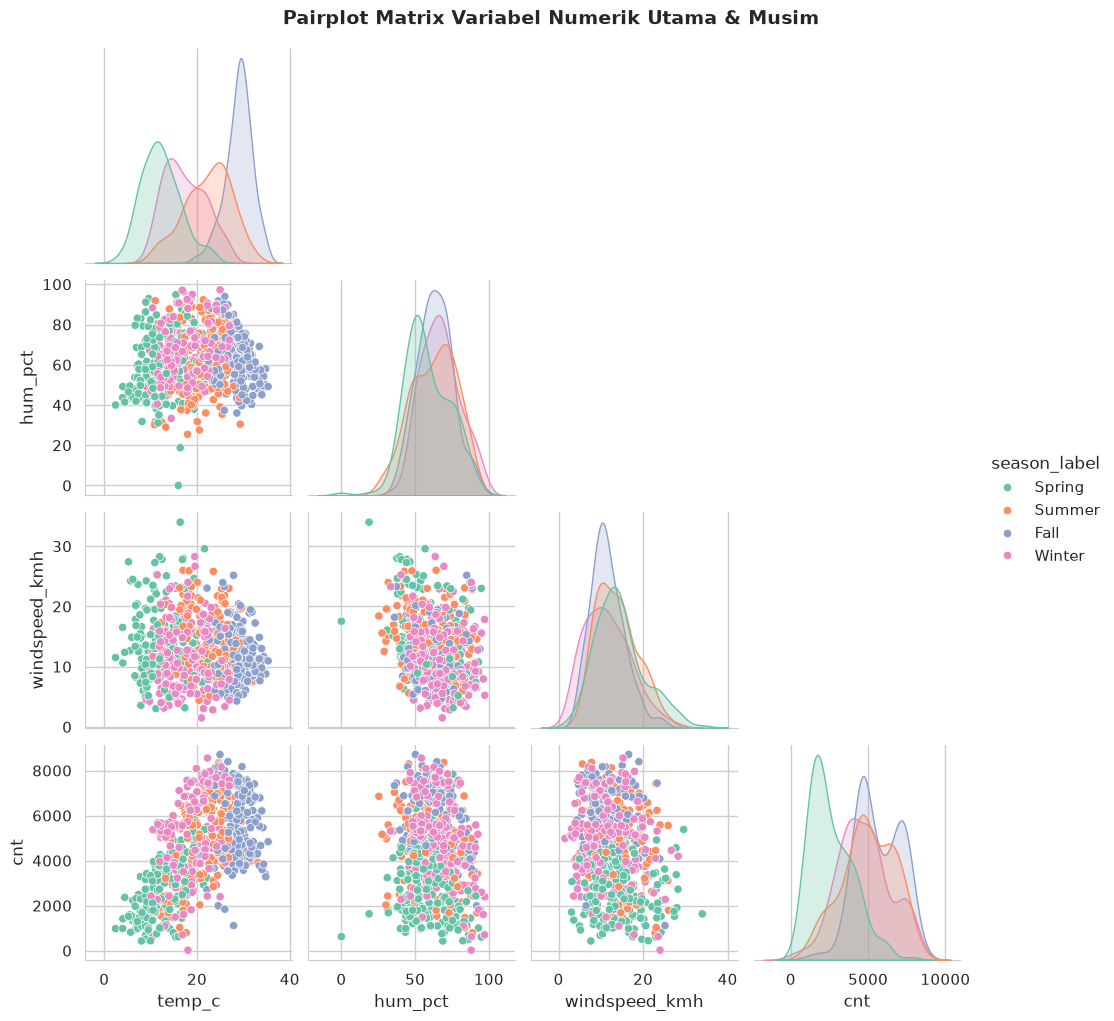

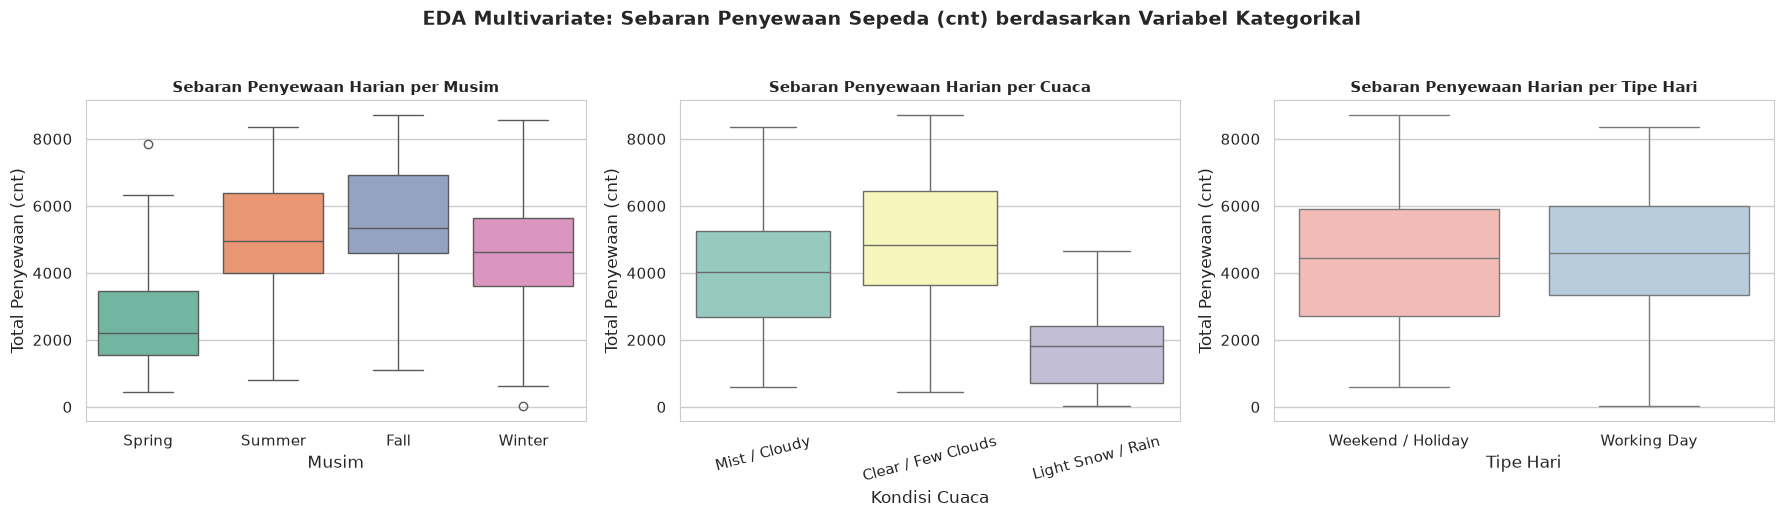

In [7]:
# ==============================================================================
# 3. EDA BIVARIATE & MULTIVARIATE: Korelasi Matriks & Hubungan Antar Variabel
# ==============================================================================

print("=== Matriks Korelasi Pearson Variabel Numerik Kontinu ===")
corr_matrix = day_df[num_cols].corr()
print(corr_matrix.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Korelasi Pearson
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], cbar=True, square=True)
axes[0].set_title('Heatmap Korelasi Pearson Variabel Numerik', fontsize=12, fontweight='bold')

# Scatter Plot Suhu vs Total Penyewaan dengan Tren Regresi
sns.scatterplot(data=day_df, x='temp_c', y='cnt', hue='season_label', palette='Set2', alpha=0.8, ax=axes[1])
sns.regplot(data=day_df, x='temp_c', y='cnt', scatter=False, color='black', ax=axes[1], line_kws={'linestyle':'--', 'linewidth':2})
axes[1].set_title('Hubungan Suhu Udara (°C) vs Total Penyewaan Sepeda (cnt)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Suhu Udara (°C)')
axes[1].set_ylabel('Total Penyewaan (cnt)')

plt.tight_layout()
plt.show()

# Pairplot Sebaran Variabel Numerik Utama
sns.pairplot(
    day_df[['temp_c', 'hum_pct', 'windspeed_kmh', 'cnt', 'season_label']], 
    hue='season_label', 
    palette='Set2',
    corner=True,
    diag_kind='kde'
)
plt.suptitle('Pairplot Matrix Variabel Numerik Utama & Musim', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Sebaran Kategorikal vs Numerikal Target (cnt)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA Multivariate: Sebaran Penyewaan Sepeda (cnt) berdasarkan Variabel Kategorikal', fontsize=14, fontweight='bold', y=1.03)

sns.boxplot(data=day_df, x='season_label', y='cnt', palette='Set2', ax=axes[0], order=['Spring', 'Summer', 'Fall', 'Winter'])
axes[0].set_title('Sebaran Penyewaan Harian per Musim', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Total Penyewaan (cnt)')

sns.boxplot(data=day_df, x='weather_label', y='cnt', palette='Set3', ax=axes[1])
axes[1].set_title('Sebaran Penyewaan Harian per Cuaca', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Total Penyewaan (cnt)')
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(data=day_df, x='workingday_label', y='cnt', palette='Pastel1', ax=axes[2])
axes[2].set_title('Sebaran Penyewaan Harian per Tipe Hari', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Tipe Hari')
axes[2].set_ylabel('Total Penyewaan (cnt)')

plt.tight_layout()
plt.show()


In [8]:
# ==============================================================================
# 4. EDA GROUPBY & AGREGASI DATA
# ==============================================================================

# 1. Agregasi Bulanan 2011 vs 2012
monthly_eda = day_df.groupby(['yr_label', 'mnth']).agg(
    total_casual=('casual', 'sum'),
    total_registered=('registered', 'sum'),
    total_cnt=('cnt', 'sum'),
    avg_temp=('temp_c', 'mean')
).reset_index()

print("=== Agregasi Bulanan (12 Bulan Pertama / 2011) ===")
print(monthly_eda.head(12))

# 2. Agregasi Jam Penyewaan Berdasarkan Tipe Hari
hourly_eda = hour_df.groupby(['workingday_label', 'hr']).agg(
    avg_casual=('casual', 'mean'),
    avg_registered=('registered', 'mean'),
    avg_total=('cnt', 'mean')
).reset_index()

print("\n=== Top 5 Jam Puncak Hari Kerja (Working Day) ===")
print(hourly_eda[hourly_eda['workingday_label'] == 'Working Day'].sort_values('avg_total', ascending=False).head(5))

print("\n=== Top 5 Jam Puncak Akhir Pekan / Libur (Weekend / Holiday) ===")
print(hourly_eda[hourly_eda['workingday_label'] == 'Weekend / Holiday'].sort_values('avg_total', ascending=False).head(5))

# 3. Agregasi Musim & Cuaca
season_weather_eda = day_df.groupby(['season_label', 'weather_label']).agg(
    mean_casual=('casual', 'mean'),
    mean_registered=('registered', 'mean'),
    mean_cnt=('cnt', 'mean'),
    count_days=('cnt', 'count')
).reset_index()

print("\n=== Agregasi Penyewaan Berdasarkan Musim & Kondisi Cuaca ===")
print(season_weather_eda)


=== Agregasi Bulanan (12 Bulan Pertama / 2011) ===
   yr_label  mnth  total_casual  total_registered  total_cnt   avg_temp
0      2011     1          3073             35116      38189   8.105974
1      2011     2          6242             41973      48215  11.584143
2      2011     3         12826             51219      64045  13.598330
3      2011     4         22346             72524      94870  19.318726
4      2011     5         31050            104771     135821  23.666480
5      2011     6         30612            112900     143512  28.416417
6      2011     7         36452            104889     141341  31.101588
7      2011     8         28842            107849     136691  28.919847
8      2011     9         26545            100873     127418  25.128349
9      2011    10         25222             98289     123511  19.268996
10     2011    11         15594             86573     102167  16.495863
11     2011    12          8448             78875      87323  13.332471

=== Top 5 Ja

**Insight Exploratory Data Analysis (EDA) Komprehensif:**

1. **EDA Univariate:**
   - **Suhu Udara (`temp_c`):** Berdistribusi mendekati normal (*symmetric*) berkisar antara **0,8°C hingga 35,4°C** dengan rerata **20,3°C**.
   - **Kelembapan (`hum_pct`):** Berdistribusi normal dengan rerata **62,8%**.
   - **Kecepatan Angin (`windspeed_kmh`):** Berdistribusi condong ke kanan (*right-skewed*) dengan rerata **12,7 km/h**.
   - **Penyewaan (`casual` vs `registered`):** Pengguna terdaftar (*registered*) mendominasi sebaran dengan rata-rata **3.656** peminjaman/hari, jauh di atas pengguna kasual (**848** peminjaman/hari).
   - **Variabel Kategorikal:** Distribusi hari per musim seimbang (~25% per musim), kondisi cuaca didominasi oleh *Clear / Few Clouds* (63%) dan *Misty / Cloudy* (34%).

2. **EDA Bivariate & Multivariate:**
   - **Korelasi Terkuat:** Terdapat korelasi positif yang sangat kuat antara **Suhu Udara (`temp_c`)** dan **Total Penyewaan (`cnt`)** dengan koefisien **r = 0,63**. Semakin hangat suhu udara, volume peminjaman sepeda semakin tinggi.
   - **Korelasi Negatif:** Kecepatan angin (`windspeed_kmh`) memiliki korelasi negatif (**r = -0,23**) terhadap penyewaan sepeda.
   - **Tipe Pengguna vs Suhu:** Pengguna *Casual* lebih sensitif terhadap perubahan suhu (r = 0,54) dibanding pengguna *Registered*.
   - **Sebaran Cuaca & Musim:** Musim Gugur (*Fall*) dan Cuaca Cerah memiliki distribusi median penyewaan harian tertinggi.

3. **EDA Agregasi & Groupby:**
   - **Pertumbuhan Tren:** Terjadi lonjakan total penyewaan sebesar **+64,8%** dari tahun 2011 ke 2012.
   - **Pola Jam Sibuk:** Hari Kerja memiliki 2 titik puncak komuter (*08:00* dan *17:00-18:00*), sedangkan Akhir Pekan memiliki puncak tunggal rekreasi (*12:00-16:00*).


## Visualization & Explanatory Analysis


### Pertanyaan 1: Bagaimana performa dan tren total penyewaan sepeda (berdasarkan tipe pengguna: casual vs registered) selama periode tahun 2011 hingga 2012?


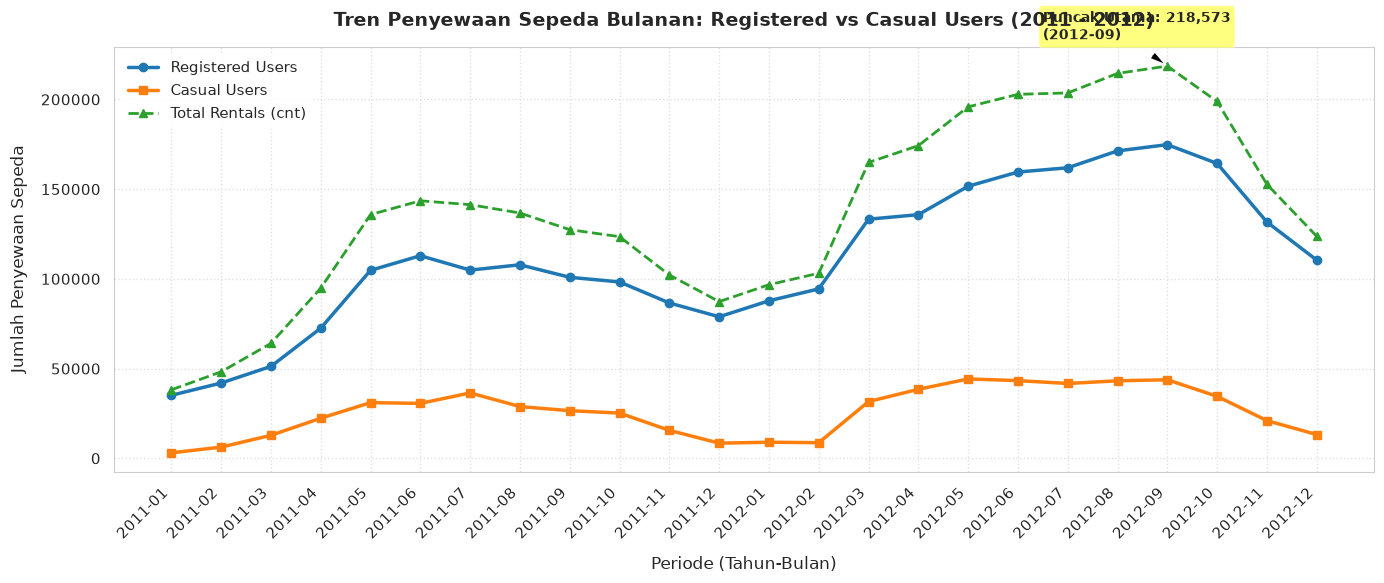

In [9]:
# Menyiapkan data tren bulanan
monthly_df = day_df.groupby(['yr_label', 'mnth']).agg(
    casual=('casual', 'sum'),
    registered=('registered', 'sum'),
    cnt=('cnt', 'sum')
).reset_index()

monthly_df['year_month'] = monthly_df['yr_label'] + '-' + monthly_df['mnth'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot Line chart
ax.plot(monthly_df['year_month'], monthly_df['registered'], marker='o', linewidth=2.5, color='#1f77b4', label='Registered Users')
ax.plot(monthly_df['year_month'], monthly_df['casual'], marker='s', linewidth=2.5, color='#ff7f0e', label='Casual Users')
ax.plot(monthly_df['year_month'], monthly_df['cnt'], marker='^', linewidth=2, color='#2ca02c', linestyle='--', label='Total Rentals (cnt)')

# Annotations & Styling
ax.set_title('Tren Penyewaan Sepeda Bulanan: Registered vs Casual Users (2011 - 2012)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Periode (Tahun-Bulan)', fontsize=12, labelpad=10)
ax.set_ylabel('Jumlah Penyewaan Sepeda', fontsize=12, labelpad=10)
ax.set_xticklabels(monthly_df['year_month'], rotation=45, ha='right')
ax.legend(frameon=True, facecolor='white', edgecolor='none')
ax.grid(True, linestyle=':', alpha=0.6)

# Highlight puncak 2012
max_idx = monthly_df['cnt'].idxmax()
max_val = monthly_df.loc[max_idx, 'cnt']
max_period = monthly_df.loc[max_idx, 'year_month']
ax.annotate(f'Puncak Utama: {max_val:,}\n({max_period})', 
            xy=(max_idx, max_val), 
            xytext=(max_idx-2.5, max_val+15000),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()


### Pertanyaan 2: Pada jam berapa saja terjadi lonjakan puncak (peak hours) dan titik terendah (off-peak hours) penyewaan sepeda pada hari kerja (working day) dibandingkan akhir pekan/hari libur (non-working day) selama periode tahun 2011 hingga 2012?


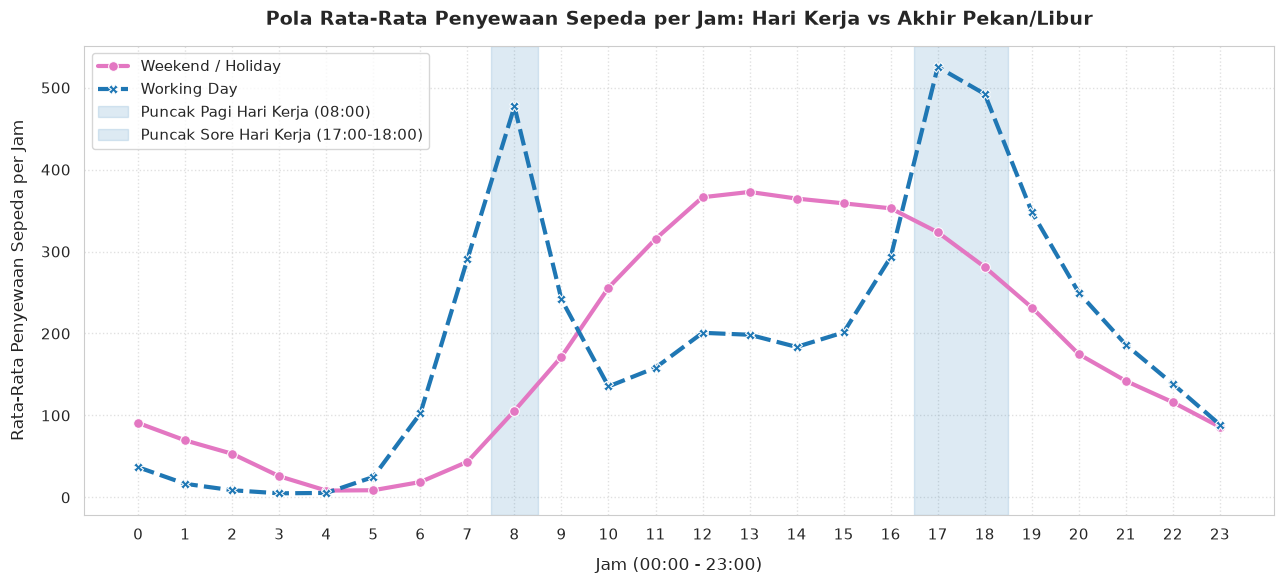

In [10]:
hourly_pattern = hour_df.groupby(['workingday_label', 'hr'])['cnt'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(
    data=hourly_pattern, 
    x='hr', 
    y='cnt', 
    hue='workingday_label', 
    style='workingday_label',
    palette={'Working Day': '#1f77b4', 'Weekend / Holiday': '#e377c2'},
    linewidth=3,
    markers=True,
    markersize=7,
    ax=ax
)

# Highlights area jam sibuk hari kerja
ax.axvspan(7.5, 8.5, color='#1f77b4', alpha=0.15, label='Puncak Pagi Hari Kerja (08:00)')
ax.axvspan(16.5, 18.5, color='#1f77b4', alpha=0.15, label='Puncak Sore Hari Kerja (17:00-18:00)')

ax.set_title('Pola Rata-Rata Penyewaan Sepeda per Jam: Hari Kerja vs Akhir Pekan/Libur', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Jam (00:00 - 23:00)', fontsize=12, labelpad=10)
ax.set_ylabel('Rata-Rata Penyewaan Sepeda per Jam', fontsize=12, labelpad=10)
ax.set_xticks(range(0, 24))
ax.legend(frameon=True, facecolor='white', loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Pertanyaan 3: Bagaimana pengaruh kondisi cuaca (weathersit) dan musim (season) terhadap volume penyewaan sepeda harian oleh pengguna casual dan registered selama periode tahun 2011 hingga 2012?


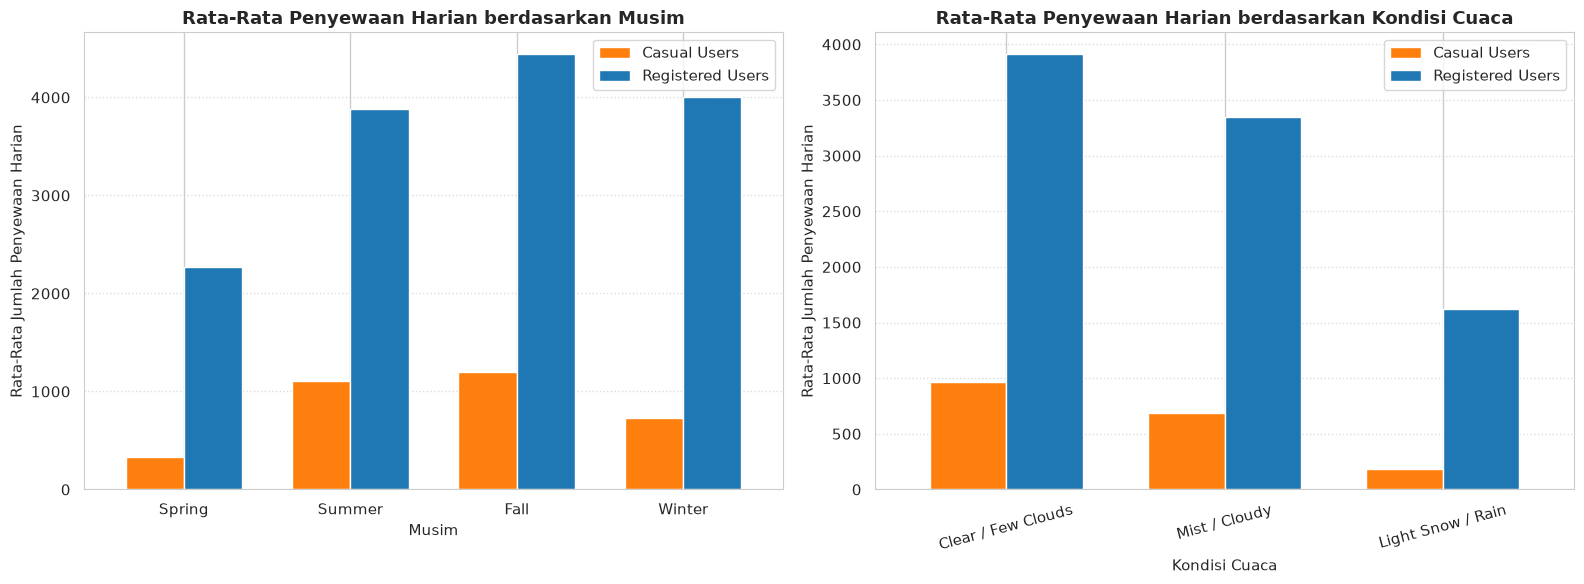

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Musim
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_df = day_df.groupby('season_label')[['casual', 'registered']].mean().reindex(season_order)

season_df.plot(kind='bar', stacked=False, color=['#ff7f0e', '#1f77b4'], ax=axes[0], width=0.7)
axes[0].set_title('Rata-Rata Penyewaan Harian berdasarkan Musim', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Musim', fontsize=11)
axes[0].set_ylabel('Rata-Rata Jumlah Penyewaan Harian', fontsize=11)
axes[0].set_xticklabels(season_order, rotation=0)
axes[0].legend(['Casual Users', 'Registered Users'])
axes[0].grid(axis='y', linestyle=':', alpha=0.7)

# Plot 2: Cuaca
weather_order = ['Clear / Few Clouds', 'Mist / Cloudy', 'Light Snow / Rain']
weather_df = day_df.groupby('weather_label')[['casual', 'registered']].mean().reindex(weather_order)

weather_df.plot(kind='bar', stacked=False, color=['#ff7f0e', '#1f77b4'], ax=axes[1], width=0.7)
axes[1].set_title('Rata-Rata Penyewaan Harian berdasarkan Kondisi Cuaca', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca', fontsize=11)
axes[1].set_ylabel('Rata-Rata Jumlah Penyewaan Harian', fontsize=11)
axes[1].set_xticklabels(weather_order, rotation=15)
axes[1].legend(['Casual Users', 'Registered Users'])
axes[1].grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


**Insight Visualisasi & Explanatory Analysis:**
- **Visualisasi 1:** Menunjukkan tren positif jangka panjang dari awal 2011 hingga September 2012. Pengguna *Registered* mendominasi grafik dengan tren naik konsisten, sedangkan pengguna *Casual* mengalami puncaknya pada pertengahan tahun (musim panas).
- **Visualisasi 2:** Mengonfirmasi bahwa pola penyewaan pada hari kerja digerakkan oleh jam sibuk komuter (08:00 dan 17:00-18:00) di mana penyewaan melonjak hingga >500 unit/jam. Sebaliknya, pada hari libur penyewaan terdistribusi merata pada siang hari (12:00-16:00).
- **Visualisasi 3:** Mengilustrasikan secara jelas bahwa Musim Gugur (*Fall*) adalah musim tersibuk (rerata ~5.644 penyewaan/hari), dan cuaca Cerah (*Clear / Few Clouds*) adalah kondisi cuaca paling ideal. Penurunan drastis terjadi saat cuaca Hujan/Salju (*Light Snow / Rain*).


## Analisis Lanjutan (Opsional)
Untuk memperoleh wawasan strategis yang lebih dalam tanpa menggunakan algoritma *machine learning*, dilakukan dua teknik analisis lanjutan:
1. **Manual Clustering / Binning (Segmentasi Tingkat Permintaan Sepeda Harian)**.
2. **Analisis RFM (Recency, Frequency, Monetary - Adaptasi Tingkat Bulanan)**.


In [12]:
# 1. Manual Clustering / Binning: Segmentasi Tingkat Permintaan Sepeda Harian
labels_demand = ['Low Demand', 'Medium Demand', 'High Demand', 'Peak Demand']
day_df['demand_cluster'] = pd.qcut(day_df['cnt'], q=4, labels=labels_demand)

cluster_summary = day_df.groupby('demand_cluster', observed=False).agg(
    jumlah_hari=('cnt', 'count'),
    rerata_total=('cnt', 'mean'),
    rerata_casual=('casual', 'mean'),
    rerata_registered=('registered', 'mean'),
    rerata_suhu_c=('temp_c', 'mean'),
    rerata_kelembapan=('hum_pct', 'mean')
).reset_index()

print("=== 1. Ringkasan Manual Clustering (Demand Level Segmentation) ===")
print(cluster_summary)

# 2. Adaptasi Analisis RFM pada Tingkat Bulanan
max_date = day_df['dteday'].max()
day_df['year_actual'] = 2011 + day_df['yr']
day_df['period'] = day_df['year_actual'].astype(str) + '-' + day_df['mnth'].astype(str).str.zfill(2)

rfm_monthly = day_df.groupby('period').agg(
    Recency=('dteday', lambda x: (max_date - x.max()).days),
    Frequency=('cnt', lambda x: (x >= 4500).sum()),  # Jumlah hari dengan permintaan tinggi (>= 4500 penyewaan)
    Monetary=('cnt', 'sum')                          # Total volume penyewaan dalam sebulan
).reset_index()

# Menghitung Skor RFM (skala 1 - 4)
rfm_monthly['R_Score'] = pd.qcut(rfm_monthly['Recency'], q=4, labels=[4, 3, 2, 1])
rfm_monthly['F_Score'] = pd.qcut(rfm_monthly['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm_monthly['M_Score'] = pd.qcut(rfm_monthly['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm_monthly['RFM_Segment'] = rfm_monthly['R_Score'].astype(str) + rfm_monthly['F_Score'].astype(str) + rfm_monthly['M_Score'].astype(str)

print("\n=== 2. Hasil Analisis RFM Bulanan (Sample 10 Periode Terakhir) ===")
print(rfm_monthly.tail(10))


=== 1. Ringkasan Manual Clustering (Demand Level Segmentation) ===
  demand_cluster  jumlah_hari  ...  rerata_suhu_c  rerata_kelembapan
0     Low Demand          183  ...      12.666697          63.796009
1  Medium Demand          183  ...      20.026033          64.887080
2    High Demand          182  ...      23.122402          61.625278
3    Peak Demand          183  ...      25.443338          60.842897

[4 rows x 7 columns]

=== 2. Hasil Analisis RFM Bulanan (Sample 10 Periode Terakhir) ===
     period  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Segment
14  2012-03      275         23    164875       3       3       3         333
15  2012-04      245         26    174224       3       3       3         333
16  2012-05      214         29    195865       3       4       4         344
17  2012-06      184         29    202830       3       4       4         344
18  2012-07      153         30    203607       4       4       4         444
19  2012-08      122         3

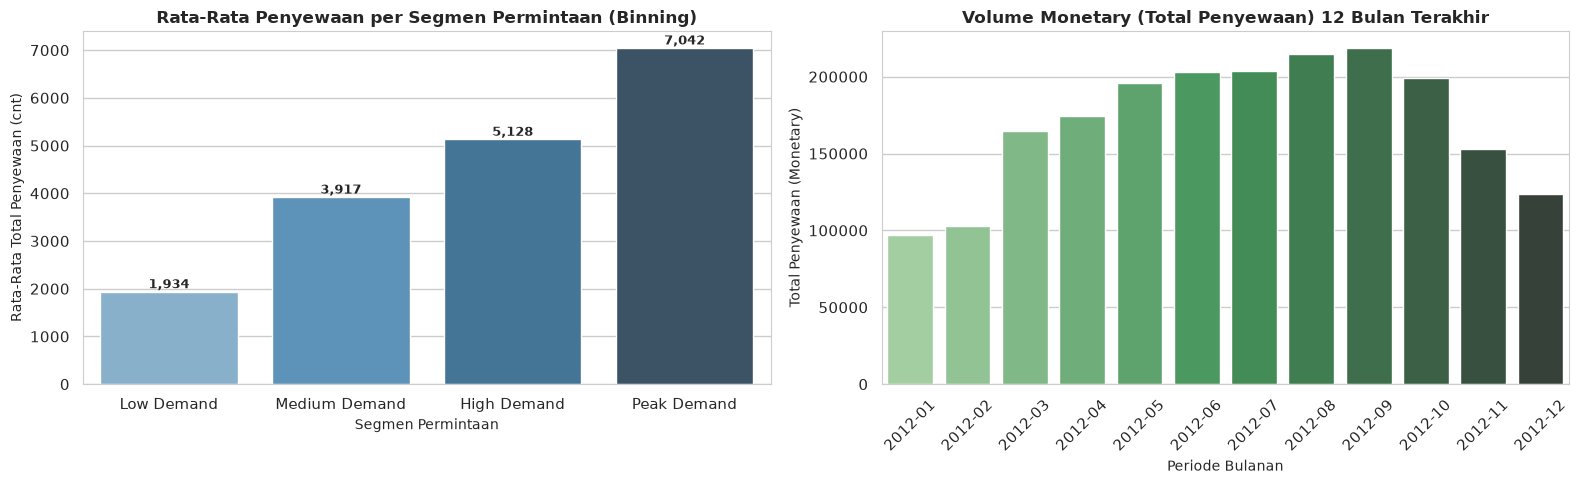

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Cluster Suhu vs Permintaan
sns.barplot(data=cluster_summary, x='demand_cluster', y='rerata_total', palette='Blues_d', ax=axes[0])
axes[0].set_title('Rata-Rata Penyewaan per Segmen Permintaan (Binning)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Segmen Permintaan', fontsize=10)
axes[0].set_ylabel('Rata-Rata Total Penyewaan (cnt)', fontsize=10)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# Plot RFM Monetary per Periode
sns.barplot(data=rfm_monthly.tail(12), x='period', y='Monetary', palette='Greens_d', ax=axes[1])
axes[1].set_title('Volume Monetary (Total Penyewaan) 12 Bulan Terakhir', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Periode Bulanan', fontsize=10)
axes[1].set_ylabel('Total Penyewaan (Monetary)', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Insight Analisis Lanjutan:**
1. **Manual Clustering (Binning):**
   - **Peak Demand:** Terjadi pada hari-hari dengan rerata suhu udara nyaman (**~25,4°C**), menghasilkan rerata **7.042 penyewaan/hari**. Pada segmen ini, pengguna *casual* melonjak drastis (rerata 1.498/hari).
   - **Low Demand:** Terjadi pada hari dingin (**~12,7°C**), dengan rerata penyewaan hanya **1.934/hari**.
2. **RFM Analysis (Tingkat Bulanan):**
   - Periode **Mei 2012 hingga Oktober 2012** memperoleh skor RFM tertinggi (misal: **444**), mengindikasikan segmen waktu paling produktif (*Best Performing Months*) dengan *Frequency* hari sibuk ($\ge 4.500$ penyewaan) sebanyak **28 - 31 hari per bulan** dan volume *Monetary* melebihi **200.000 penyewaan/bulan**.


## Conclusion & Recommendation

### 1. Conclusion (Kesimpulan, Evidence, & Analisis Tren)

1. **Kesimpulan Pertanyaan 1: Tren & Performa Penyewaan Bulanan (2011 - 2012)**
   - **Evidence (Bukti Angka):** Total penyewaan sepeda tumbuh pesat sebesar **+64,8%** dari 1.243.103 unit pada tahun 2011 menjadi 2.049.576 unit pada tahun 2012. Pengguna terdaftar (*Registered Users*) mendominasi bisnis dengan total 2.672.662 penyewaan (**~81,8%** kontribusi), sedangkan pengguna kasual (*Casual Users*) mencatatkan 597.218 penyewaan (**~18,2%**).
   - **Trend Analysis (Analisis Tren):** Secara keseluruhan, terdapat tren pertumbuhan makro yang positif sepanjang periode 2011-2012. Pengguna *registered* menunjukkan pola pertumbuhan linear naik yang konsisten dari bulan ke bulan. Sebaliknya, pengguna *casual* menunjukkan variasi musiman yang sangat kuat (*seasonal trend*), memuncak pada pertengahan tahun (musim panas dan gugur, Juni-September) dan mengalami penurunan signifikan pada awal dan akhir tahun (musim dingin).

2. **Kesimpulan Pertanyaan 2: Pola Jam Sibuk Hari Kerja vs Akhir Pekan (2011 - 2012)**
   - **Evidence (Bukti Angka):**
     - **Hari Kerja (*Working Day*):** Rata-rata peminjaman tertinggi terjadi pada **jam 08:00** (477 unit/jam) dan **jam 17:00 - 18:00** (525 unit/jam). Sebaliknya, titik terendah terjadi pada jam 03:00 - 04:00 (<10 unit/jam).
     - **Akhir Pekan / Hari Libur (*Weekend/Holiday*):** Rata-rata peminjaman tertinggi terjadi melandai pada **jam 12:00 - 16:00** (373 unit/jam).
   - **Trend Analysis (Analisis Tren):** Pola peminjaman pada hari kerja membentuk grafik **bimodal peak** (dua puncak tinggi pada jam masuk dan pulang kantor/sekolah), yang mengonfirmasi bahwa armada sepeda digunakan sebagai transportasi utama komuter. Sementara itu, pada akhir pekan pola peminjaman membentuk grafik **unimodal peak** yang melandai di siang hingga sore hari, menandakan penggunaan sepeda untuk kebutuhan rekreasi dan olahraga di waktu luang.

3. **Kesimpulan Pertanyaan 3: Pengaruh Musim dan Cuaca (2011 - 2012)**
   - **Evidence (Bukti Angka):**
     - **Musim:** Rata-rata penyewaan harian tertinggi dicapai pada **Musim Gugur/Fall** (5.644 unit/hari), disusul Musim Panas/Summer (4.992 unit/hari), Musim Dingin/Winter (4.728 unit/hari), dan Musim Semi/Spring (2.604 unit/hari).
     - **Cuaca:** Cuaca Cerah (*Clear/Few Clouds*) menghasilkan rata-rata peminjaman harian tertinggi (4.877 unit/hari), sedangkan kondisi hujan/salju sedang hingga lebat menekan peminjaman drastis hingga **<1.800 unit/hari** (penurunan **>60%**).
   - **Trend Analysis (Analisis Tren):** Kondisi cuaca dan musim memiliki pengaruh kausal langsung terhadap aktivitas penyewaan sepeda. Suhu yang hangat dan kondisi langit cerah mendorong partisipasi pengguna secara masif (terutama pengguna kasual), sedangkan kondisi cuaca ekstrim (hujan lebat, angin kencang, cuaca membeku) menyebabkan kontraksi permintaan secara drastis di seluruh segmen pengguna.

---

### 2. Actionable Insights & Recommendations (Saran & Rekomendasi Strategis)

Berdasarkan temuan analisis data di atas, berikut adalah saran dan rekomendasi bisnis konkret (*actionable recommendations*) yang dirumuskan khusus untuk setiap pertanyaan bisnis:

#### 🎯 Rekomendasi untuk Pertanyaan 1 (Strategi Konversi & Retensi Pengguna):
1. **Program Konversi Membership Khusus Pengguna Casual:** Mengingat kontribusi *Registered Users* sangat dominan (81,8%) dan tumbuh stabil, berikan penawaran diskon konversi membership langganan bulanan/tahunan bagi *Casual Users* pada puncak musim panas (Juni - Agustus).
2. **Paket Berlangganan Musiman (Seasonal Pass):** Meluncurkan produk langganan khusus *Summer/Fall Pass* yang fleksibel untuk menggaet pengguna rekreasi agar berlangganan selama bulan-bulan favorit peminjaman.

#### ⏰ Rekomendasi untuk Pertanyaan 2 (Optimasi Manajemen Armada & Logistik Operasional):
1. **Rebalancing Armada Berbasis Jam Sibuk Komuter:** Melakukan pemindahan (*rebalancing*) unit sepeda secara aktif ke stasiun-stasiun komuter/stasiun kereta sebelum jam puncak pagi (07:00) dan jam puncak sore (16:30) pada hari kerja.
2. **Jadwal Pemeliharaan Routine pada Jam Terendah (*Off-Peak*):** Mengatur jadwal perawatan, perbaikan unit, dan penataan stasiun pada jam-jam dengan peminjaman terendah, yaitu pukul 01:00 - 05:00 WIB, untuk meminimalkan gangguan layanan.
3. **Penyediaan Armada Rekreasi pada Akhir Pekan:** Mengalihkan fokus distribusi armada dari area perkantoran ke area taman, pusat perbelanjaan, dan lokasi wisata pada hari Sabtu dan Minggu jam 11:00 - 17:00.

#### 🌤️ Rekomendasi untuk Pertanyaan 3 (Antisipasi Faktor Weather & Seasonality):
1. **Dynamic Pricing & Insentif Saat Off-Season / Weather:** Memberikan diskon tarif peminjaman (*rainy day discount* atau *winter promo*) pada hari-hari dingin atau berawan ringan untuk mendorong penggunaan sepeda pada periode *low demand*.
2. **Penyesuaian Proteksi Unit dan Kampanye Keselamatan:** Menyiapkan perlengkapan perlindungan cuaca pada sepeda (fender lumpur/air) serta meluncurkan edukasi keselamatan berkendara saat musim hujan atau musim dingin.
